# Functional Responses

In food web ecology, we often deal with **functional responses**, or the idea that rate at which a consumer eats food in relation to the amount of food available.

We can have a:
1. Single-species functional response
2. Multi-species functional response

### Single-species functional response

For example, if there is one prey and one predator, the rate of prey consumption can scale non-linearly with predator density. One reason for this is **satiation conditions**. Here, if prey density is low, predator consumption rate is higher because the predator's hunger level is higher. As prey density increases, the predator's hunger level decreases, so the consumption rate does not increase linearly with prey density. 

Another reason for a non-linear relationship between prey density and predator consumption rate is **handling time**, where an increase in prey density does not increase the consumption rate because the predator spends time handling the prey while eating, which constrains the intake of more and more prey.

In [73]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [74]:
prey_density = np.arange(0, 100, 1)
attack = 0.8
handling = 0.1

func_response = attack * prey_density / (1 + attack * handling * prey_density)

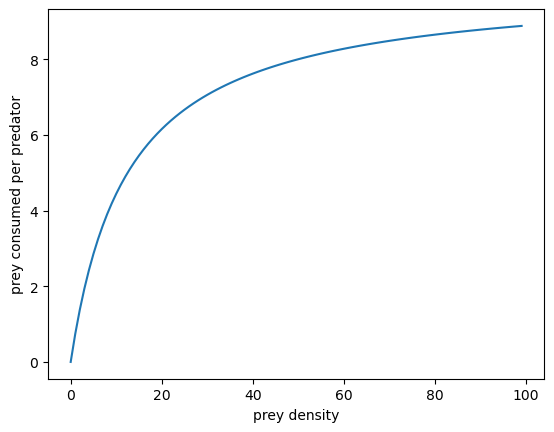

In [75]:
plt.plot(prey_density, func_response)
plt.xlabel("prey density")
plt.ylabel("prey consumed per predator")
plt.show()

### Multi-species functional response

In a multi-species functional response, the rate of prey consumption can be a function of 
1) the abundance of total prey in the prey community and
2) the composition of the multi-species prey community.

#### Prey composition (i.e., proportion)

First we will focus on a multi-species functional response where the predation rate is a function of the prey community composition, or the proportion of prey in the prey community.

$L$ = abundance of lamprey

$S$ = abundance of salmon

$L_f$ = L / (L + S) = proportion of lamprey in community

$S_f$ = S / (L + S) = proportion of salmon in community

$L_{prey}$ = number of lamprey eaten per pinniped

$S_{prey}$ = number of salmon eaten per pinniped


Per pinniped predation rate:

$L_{prey} = \frac{a_L \times L_f^{m_L}}{P^{b}+ h (a_L \times L_f^{m_L} + a_S \times S_f^{m_S})}$

$S_{prey} = \frac{a_S \times S_f^{m_S}}{P^{b}+ h (a_L \times L_f^{m_L} + a_S \times S_f^{m_S})}$

In [69]:
# get parameters
params = {
    "pred_m": [1, 1], # prey switching exponents [lamprey, salmon], 1 = no switching
    "pred_a": [0.1, 0.03], # prey attack rate, similar to preference [lamprey, salmon]
    "pred_b": 0.3, # strength of predator density-dependence
    "pred_h": 0.1, # predator handling time
    "total": 500000, # total abundance of prey
    "P": 300 # abundance of pinnipeds
} 

In [70]:
# function to get functional response using prey composition 
def predation_prop(params, L_f, S_f, P):
    x = np.array([L_f, S_f])
    
    # Calculate the denominator
    denominator = (
        P ** params["pred_b"] + params["pred_h"] * np.sum(params["pred_a"] * x ** params["pred_m"])
    )
    
    # get L and S prey per predator
    L_prey = params["pred_a"][0] * L_f ** params["pred_m"][0] / denominator
    S_prey = params["pred_a"][1] * S_f ** params["pred_m"][1] / denominator
    
    return [L_prey, S_prey]

In [71]:
# plot per pinniped predation rate
def plot_fr(params):
    # get number of prey based on proportion of total of each fish
    df = pd.DataFrame(columns=['L_prop', 'S_prop', 'L_prey','S_prey'])
    df['L_prop'] = np.arange(0, 1, 0.01)
    df['S_prop'] = np.arange(0, 1, 0.01)[::-1]

    for index, row in df.iterrows():
        # get prey per pinniped
        prey = predation_prop(params, L = row['L_prop'] * params['total'], 
                              S = row['S_prop'] * params['total'], P = params['P'])
    
        # add to df
        df.at[index, 'L_prey'] = prey[0]
        df.at[index, 'S_prey'] = prey[1]

    # Plot the result
    plt.figure(figsize=(8, 6))
    plt.plot(np.arange(0, 1, 0.01), 
             df['L_prey'], color='red', label='Lamprey')
    plt.plot(np.arange(0, 1, 0.01), 
             df['S_prey'], color='blue', label='Salmon')
    plt.xlabel("proportion of prey community = lamprey")
    plt.ylabel("prey consumed per pinniped")
    plt.legend()
    plt.show()


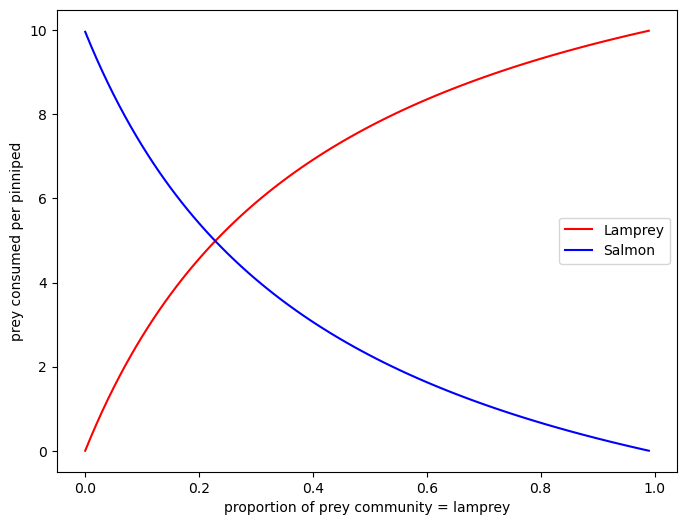

In [72]:
plot_fr(params)

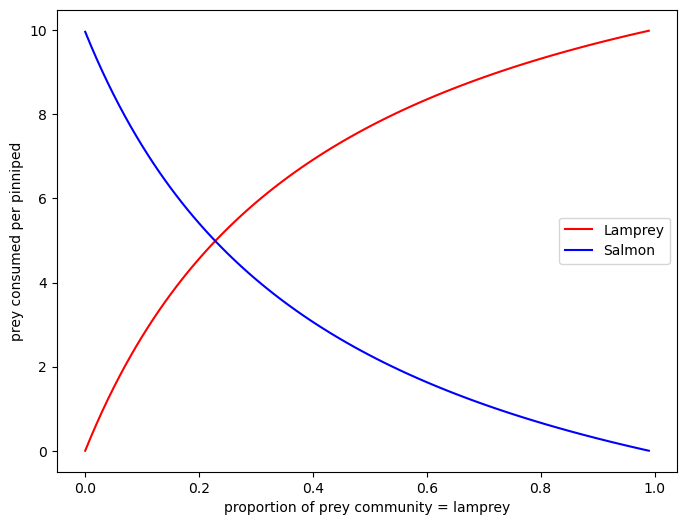

In [81]:
params["pred_m"] = [1, 1] 
plot_fr(params)

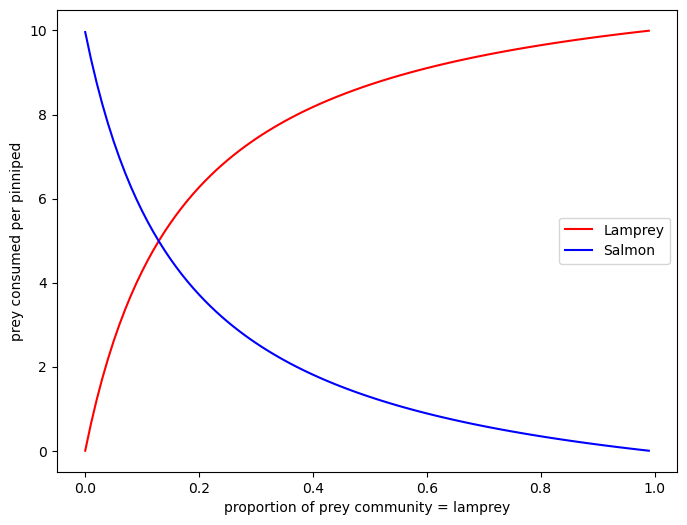

In [82]:
params["pred_a"] = [0.2, 0.03] 
plot_fr(params)